**전이 학습**


In [1]:
pip install opencv-python

In [2]:
#라이브러리 호출
import os
import time
import copy
import glob
import cv2
import shutil

import torch
import torchvision
import torchvision.transforms as transforms # 데이터 전처리
import torchvision.models as models # 사전 훈련된 모델을 가져올 수 있도록 함
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

In [3]:
import numpy as np

In [4]:
import os

# API 토큰 설정
os.environ['KAGGLE_API_TOKEN'] = "KGAT_e8e62cb7bb85abd8d25748922bf40184"

# 공개 데이터셋 다운로드 (별도 규정 동의 불필요)
!kaggle datasets download -d chetankv/dogs-cats-images

# dataset 폴더에 압축 해제
!unzip -q dogs-cats-images.zip -d ./dataset

Dataset URL: https://www.kaggle.com/datasets/chetankv/dogs-cats-images
License(s): CC0-1.0
100% 435M/435M [00:07<00:00, 62.2MB/s]



In [5]:
#이미지 데이터 전처리 방법 정의

data_path = './dataset/dataset/training_set'

transforms= transforms.Compose(
    [
        transforms.Resize([256, 256]), # 이미지 크기 256x256으로 조정 (합성곱층에 넣기 위한 전처리)
        transforms.RandomResizedCrop(224), # 랜덤한 크기 및 비율로 crop (데이터 확장 용도)
        transforms.RandomHorizontalFlip(), # 이미지를 랜덤하게 수평 뒤집음
        transforms.ToTensor() # 이미지를 텐서로 변환
    ]
)

train_dataset = torchvision.datasets.ImageFolder(
    data_path, # 첫 번째 파라미터로 데이터가 위치한 경로
    transform=transforms # 이미지 데이터에 대한 전처리
)

train_loader=torch.utils.data.DataLoader(
    train_dataset, # 데이터셋 지정
    batch_size=32, # 한 번에 불러올 데이터양
    num_workers=8, # 데이터 불러올 때의 하위 프로세스를 몇 개 사용할지 설정
    shuffle=True # 무작위로 섞어서 랜덤으로 불러옴
)  #

print(len(train_dataset))

8000


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


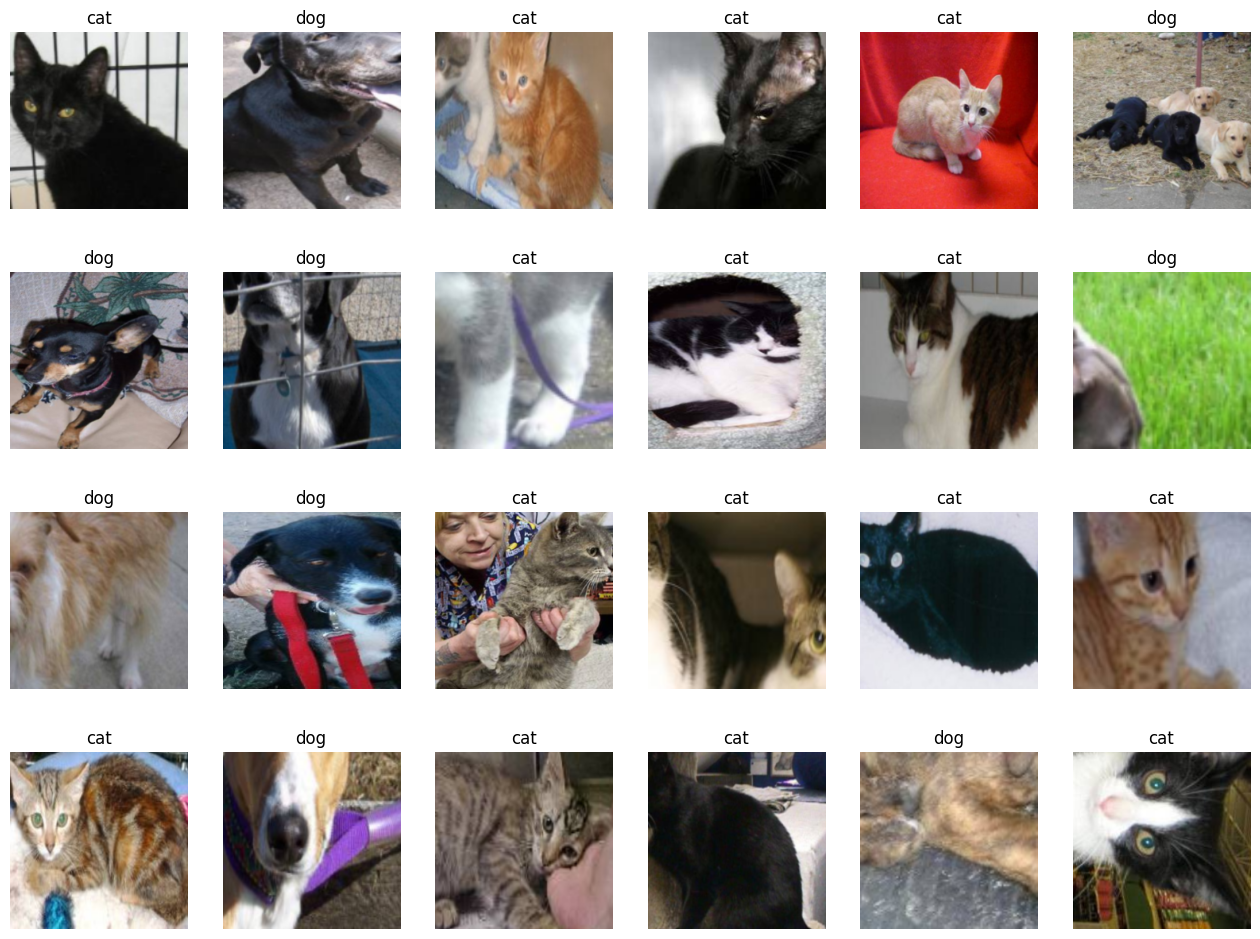

In [6]:
# 학습에 사용될 이미지 출력

samples, labels =next(iter(train_loader))
# 반복자는 train_loader가 되기 떄문에 train_loader에서 samples와 labels의 값을 순차적으로 꺼내서 저장
classes = {0:'cat', 1:'dog'}
fig = plt.figure(figsize=(16, 24))
for i in range(24):
  a = fig.add_subplot(4, 6, i+1)
  a.set_title(classes[labels[i].item()])
  a.axis('off')
  a.imshow(np.transpose(samples[i].numpy(), (1, 2, 0))) # np.transpose는 전치행렬의 역할을
plt.subplots_adjust(bottom=0.2, top=0.6,hspace=0)

In [7]:
# 사전 훈련된 모델 내려받기

resnet18 = models.resnet18(pretrained=True) # 사전 학습되니 가중치를 사용하겠다는 의미

/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 161MB/s]


In [8]:
# 사전 훈련된 모델의 파라미터 학습 유무 지정

def set_parameter_requires_grad(model, feature_extracting=True):
  if feature_extracting:
    for param in model.parameters():
      param.set_parameter_requires_grad=False # 역전파에서 계산할 필요 없음을 나타냄.
# 즉 모델의 일부(합성곱층과 풀링층)를 고정하고 나머지를 학습하고자 할 때 사용함.

set_parameter_requires_grad(resnet18)

In [9]:
# ResNet18에 완전연결층 추가

resnet18.fc=nn.Linear(512, 2)

In [10]:
# 그냥 모델의 파라미터값 확인

for name, param in resnet18.named_parameters():
  if param.requires_grad:
    print(name, param.data)

conv1.weight tensor([[[[-1.0419e-02, -6.1356e-03, -1.8098e-03,  ...,  5.6615e-02,
            1.7083e-02, -1.2694e-02],
          [ 1.1083e-02,  9.5276e-03, -1.0993e-01,  ..., -2.7124e-01,
           -1.2907e-01,  3.7424e-03],
          [-6.9434e-03,  5.9089e-02,  2.9548e-01,  ...,  5.1972e-01,
            2.5632e-01,  6.3573e-02],
          ...,
          [-2.7535e-02,  1.6045e-02,  7.2595e-02,  ..., -3.3285e-01,
           -4.2058e-01, -2.5781e-01],
          [ 3.0613e-02,  4.0960e-02,  6.2850e-02,  ...,  4.1384e-01,
            3.9359e-01,  1.6606e-01],
          [-1.3736e-02, -3.6746e-03, -2.4084e-02,  ..., -1.5070e-01,
           -8.2230e-02, -5.7828e-03]],

         [[-1.1397e-02, -2.6619e-02, -3.4641e-02,  ...,  3.2521e-02,
            6.6221e-04, -2.5743e-02],
          [ 4.5687e-02,  3.3603e-02, -1.0453e-01,  ..., -3.1253e-01,
           -1.6051e-01, -1.2826e-03],
          [-8.3730e-04,  9.8420e-02,  4.0210e-01,  ...,  7.0789e-01,
            3.6887e-01,  1.2455e-01],
       

In [11]:
# 모델 객체 생성 및 손실 함수 정의

model = models.resnet18(pretrained=True) # 모델의 객체 생성

for param in model.parameters(): # 모델의 합성곱층 가중치 고정
  param.requires_grad = False

model.fc = torch.nn. Linear(512, 2)
for param in model.fc.parameters(): # 완전연결층은 학습
  param.requires_grad = True

optimizer = torch.optim.Adam(model.fc.parameters())
cost = torch.nn.CrossEntropyLoss() #손실 함수 정의
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [24]:
# 모델 학습을 위한 함수 생성

def train_model(model, dataloaders, criterion, optimizer, device, num_epochs=13, is_train=True) :
  since = time.time() # 컴퓨터의 현재 시각을 구하는 함수
  acc_history = []
  loss_history = []
  best_acc = 0.0

  for epoch in range(num_epochs) : # 에포크(13)만큼 반복
    print('Epoch {}/{}'.format(epoch, num_epochs-1))
    print('-'*10)

    running_loss = 0.0
    running_corrects = 0

    for inputs, labels in dataloaders: # 데이터 로더에 전달된 데이터만큼 반복
        inputs = inputs.to(device)
        labels = labels.to(device)

        model.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        _, preds = torch.max(outputs,1)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()*inputs.size(0) # 출력 결과와 레이블의 오차를 계산한 결과를 누적하여 저장
        running_corrects += torch.sum(preds == labels.data) # 출력 결과와 레이블이 동일한지 확인한 결과를 누적하여 저장

    epoch_loss = running_loss/len(dataloaders.dataset) # 평균 오차 계산
    epoch_acc = running_corrects.double()/len(dataloaders.dataset)  # 평균 정확도 계산

    print('Loss: {:.4f}  Acc:{:.4f}'.format(epoch_loss, epoch_acc))

    if epoch_acc > best_acc:
      best_acc = epoch_acc

    acc_history.append(epoch_acc.item())
    loss_history.append(epoch_loss)
    torch.save(model.state_dict(), os.path.join('./dataset/dataset/training_set', f'{epoch:02d}.pth'))    # 모델 재사용을 위한 저장
    print()

  time_elapsed = time.time() - since # 실행 시간을 계산
  print('Training complete in {:.0f}m {:.0f}s'.format(time_elapsed//60, time_elapsed%60))
  print('Best Acc: {:4f}'.format(best_acc))
  return acc_history, loss_history # 모델의 정확도와 오차를 반환

In [25]:
# 파라미터 학습 결과를 옵티마이저에 전달

params_to_update = []
for name, param in resnet18.named_parameters():
  if param.requires_grad == True :
      params_to_update.append(param)
      print('\t', name)

optimizer = optim.Adam(params_to_update)

	 conv1.weight
	 bn1.weight
	 bn1.bias
	 layer1.0.conv1.weight
	 layer1.0.bn1.weight
	 layer1.0.bn1.bias
	 layer1.0.conv2.weight
	 layer1.0.bn2.weight
	 layer1.0.bn2.bias
	 layer1.1.conv1.weight
	 layer1.1.bn1.weight
	 layer1.1.bn1.bias
	 layer1.1.conv2.weight
	 layer1.1.bn2.weight
	 layer1.1.bn2.bias
	 layer2.0.conv1.weight
	 layer2.0.bn1.weight
	 layer2.0.bn1.bias
	 layer2.0.conv2.weight
	 layer2.0.bn2.weight
	 layer2.0.bn2.bias
	 layer2.0.downsample.0.weight
	 layer2.0.downsample.1.weight
	 layer2.0.downsample.1.bias
	 layer2.1.conv1.weight
	 layer2.1.bn1.weight
	 layer2.1.bn1.bias
	 layer2.1.conv2.weight
	 layer2.1.bn2.weight
	 layer2.1.bn2.bias
	 layer3.0.conv1.weight
	 layer3.0.bn1.weight
	 layer3.0.bn1.bias
	 layer3.0.conv2.weight
	 layer3.0.bn2.weight
	 layer3.0.bn2.bias
	 layer3.0.downsample.0.weight
	 layer3.0.downsample.1.weight
	 layer3.0.downsample.1.bias
	 layer3.1.conv1.weight
	 layer3.1.bn1.weight
	 layer3.1.bn1.bias
	 layer3.1.conv2.weight
	 layer3.1.bn2.weight
	 layer

In [26]:
# 모델 학습

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = nn.CrossEntropyLoss()
train_acc_hist, train_loss_hist = train_model(resnet18, train_loader, criterion, optimizer, device)

Epoch 0/12
----------


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Loss: 0.1935  Acc:0.9150

Epoch 1/12
----------
Loss: 0.1793  Acc:0.9166

Epoch 2/12
----------
Loss: 0.1834  Acc:0.9131

Epoch 3/12
----------
Loss: 0.1817  Acc:0.9171

Epoch 4/12
----------
Loss: 0.1695  Acc:0.9250

Epoch 5/12
----------
Loss: 0.1677  Acc:0.9231

Epoch 6/12
----------
Loss: 0.1678  Acc:0.9244

Epoch 7/12
----------
Loss: 0.1642  Acc:0.9259

Epoch 8/12
----------
Loss: 0.1643  Acc:0.9284

Epoch 9/12
----------
Loss: 0.1563  Acc:0.9310

Epoch 10/12
----------
Loss: 0.1493  Acc:0.9345

Epoch 11/12
----------
Loss: 0.1449  Acc:0.9344

Epoch 12/12
----------
Loss: 0.1536  Acc:0.9317

Training complete in 9m 34s
Best Acc: 0.934500


In [27]:
# 테스트 데이터 호출 및 전처리

test_path = './dataset/dataset/test_set'

transform = transforms.Compose(
    [
        transforms.Resize(224),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
    ])
test_dataset = torchvision.datasets.ImageFolder(
    root=test_path,
    transform=transform
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=32,
    num_workers=1,
    shuffle=True
)

print(len(test_dataset))

2000


In [33]:
# 테스트 데이터 평가 함수 생성

def eval_model(model, dataloaders, device):
  since=time.time()
  acc_history =[]
  best_acc = 0.0

  saved_models = glob.glob('./dataset/dataset/training_set/*.pth')
  saved_models.sort # 불러온 .pth 파일들을 정렬
  print('saved_model', saved_models)

  for model_path in saved_models:
    print('Loading model', model_path)

    model.load_state_dict(torch.load(model_path))
    model.eval()
    model.to(device)
    running_corrects = 0

    for inputs, labels in dataloaders :
      inputs = inputs.to(device)
      labels = labels.to(device)

      with torch.no_grad() :  # autograd를 사용하지 않겠다는 의미
        outputs = model(inputs) # 데이터를 모델에 적용한 결과를 outputs에 저장

      _, preds = torch.max(outputs.data, 1)
      preds[preds>=0.5] = 1 # torch.max 출력값이 0.5보다 크면 올바르게 예측
      preds[preds<0.5] = 0 # # torch.max 출력값이 0.5보다 작으면 틀리게 예측
      running_corrects += preds.eq(labels).int().sum()

      epoch_acc = running_corrects.double()/len(dataloaders.dataset) # 테스트 데이터의 정확도를 계산
      print('Acc: {:.4f}'.format(epoch_acc))

      if epoch_acc > best_acc:
        best_acc=epoch_acc
        acc_history.append(epoch_acc.item())
        print()

    time_elapsed = time.time()-since
    print('Validation complete in {:.0f}m {:.0f}s'.format(time_elapsed//60, time_elapsed%60))
    print('Best Acc: {:.4f}'.format(best_acc))

    return acc_history

In [34]:
# 테스트 데이터를 평가 함수에 적용

val_acc_hist = eval_model(resnet18, test_loader, device)

saved_model ['./dataset/dataset/training_set/03.pth', './dataset/dataset/training_set/06.pth', './dataset/dataset/training_set/09.pth', './dataset/dataset/training_set/04.pth', './dataset/dataset/training_set/05.pth', './dataset/dataset/training_set/08.pth', './dataset/dataset/training_set/12.pth', './dataset/dataset/training_set/00.pth', './dataset/dataset/training_set/11.pth', './dataset/dataset/training_set/07.pth', './dataset/dataset/training_set/01.pth', './dataset/dataset/training_set/10.pth', './dataset/dataset/training_set/02.pth']
Loading model ./dataset/dataset/training_set/03.pth
Acc: 0.0150

Acc: 0.0300

Acc: 0.0450

Acc: 0.0605

Acc: 0.0765

Acc: 0.0925

Acc: 0.1075

Acc: 0.1225

Acc: 0.1380

Acc: 0.1525

Acc: 0.1665

Acc: 0.1815

Acc: 0.1970

Acc: 0.2125

Acc: 0.2280

Acc: 0.2435

Acc: 0.2585

Acc: 0.2735

Acc: 0.2880

Acc: 0.3030

Acc: 0.3180

Acc: 0.3325

Acc: 0.3480

Acc: 0.3640

Acc: 0.3785

Acc: 0.3940

Acc: 0.4090

Acc: 0.4245

Acc: 0.4400

Acc: 0.4540

Acc: 0.4685


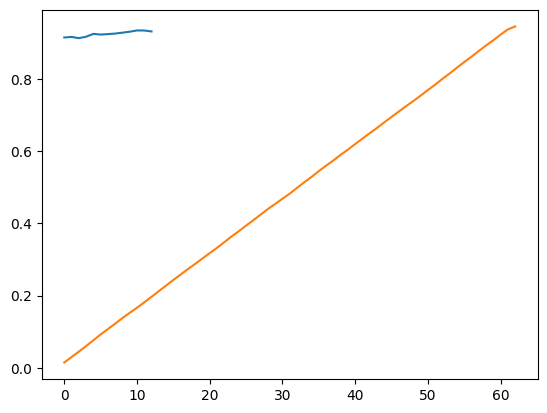

In [35]:
# 훈련과 테스트 데이터의 정확도를 그래프로 확인

plt.plot(train_acc_hist)
plt.plot(val_acc_hist)
plt.show()

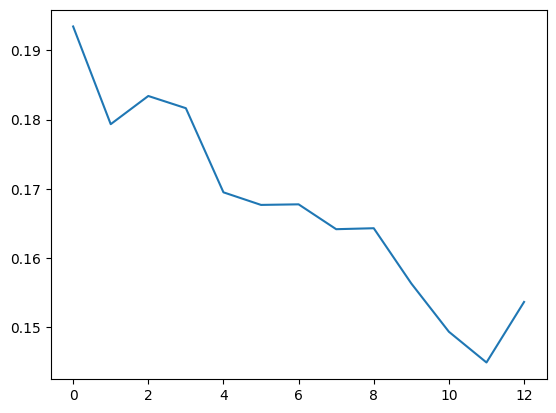

In [36]:
# 훈련 데이터의 오차에 대한 그래프 확인

plt.plot(train_loss_hist)
plt.show()

In [72]:
# 예측 이미지 출력을 위한 전처리 함수

def im_convert(tensor):
  image = tensor.cpu().clone().detach().numpy()
  image = image.transpose(1, 2, 0)
  image = image * np.array([0.5, 0.5, 0.5]) + np.array([0.5, 0.5, 0.5])
  image = image.clip(0,1)
  return image

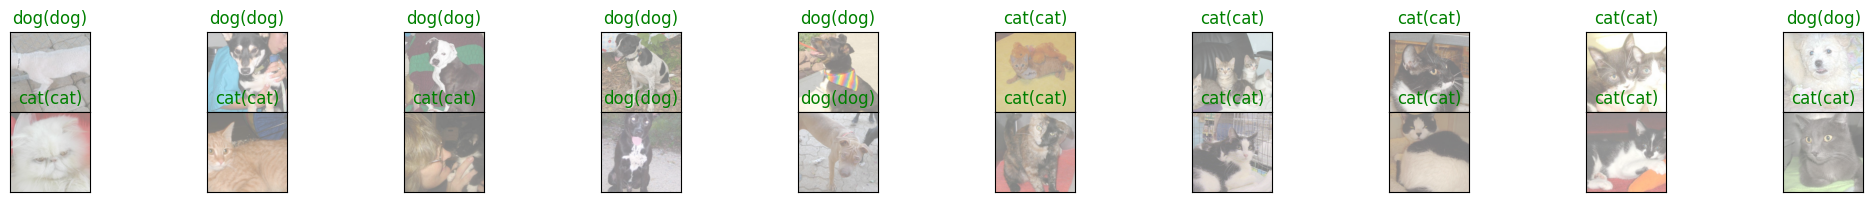

In [73]:
classes = {0: 'cat', 1: 'dog'}

dataiter = iter(test_loader)
images, labels = next(dataiter)
images = images.to(device)
output = resnet18(images)
_, preds = torch.max(output, 1)

fig = plt.figure(figsize=(25, 4))
for idx in np.arange(20):
    ax = fig.add_subplot(2, 10, idx + 1, xticks=[], yticks=[])
    plt.imshow(im_convert(images[idx].cpu()))
    ax.set_title(
        "{}({})".format(
            str(classes[preds[idx].item()]),
            str(classes[labels[idx].item()])
        ),
        color=("green" if preds[idx] == labels[idx] else "red")
    )

plt.subplots_adjust(bottom=0.2, top=0.6, hspace=0)
plt.show()

** 특성 맵 시각화**

In [92]:
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import torch
import torch.nn.functional as F
import torch.nn as nn
from torchvision.transforms import ToTensor
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [93]:
class XAI(torch.nn.Module):
  def __init__(self, num_classes=2):
    super(XAI, self).__init__()
    self.features = nn.Sequential(
        nn.Conv2d(3, 64, kernel_size=3, bias=False),
        nn.BatchNorm2d(64),
        nn.ReLU(inplace=True),
        nn.Dropout(0.3),
        nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(64),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2),

        nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(128),
        nn.ReLU(inplace=True),
        nn.Dropout(0.4),
        nn.Conv2d(128, 128, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(128),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2),

        nn.Conv2d(128, 256, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.4),
        nn.Conv2d(256, 256, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.4),
        nn.Conv2d(256, 256, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(256),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2),

        nn.Conv2d(256, 512, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(512),
        nn.ReLU(inplace=True),
        nn.Dropout(0.4),
        nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(512),
        nn.ReLU(inplace=True),
        nn.Dropout(0.4),
        nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(512),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2),

        nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(512),
        nn.ReLU(inplace=True),
        nn.Dropout(0.4),
        nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(512),
        nn.ReLU(inplace=True),
        nn.Dropout(0.4),
        nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(512),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2),
    )
    self.classifier = nn.Sequential(
        nn.Linear(512, 512, bias=False),
        nn.Dropout(0.5),
        nn.BatchNorm1d(512),
        nn.ReLU(inplace=True),
        nn.Dropout(0.5),
        nn.Linear(512, num_classes)
    )


  def forward(self, x):
    x = self.features(x)
    x = x.view(-1, 512)
    x = self.classifier(x)
    return F.log_softmax(x, dim=1)

In [94]:
#모델 객체화

model = XAI() #모델이라는 이름의 객체를 생성
model.to(device) # 모델을 장치에 할당
model.eval() # 테스트 데이터에 대한 모델 평가 용도로 사용

XAI(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Dropout(p=0.4, inplace=False)
    (12): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (13): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU(inplace=True

In [95]:
# 특성 맵을 확인하기 위한 클래스 정의

class LayerActivations:
  features=[]
  def __init__(self, model, layer_num):
    self.hook = model[layer_num].register_forward_hook(self.hook_fn)
  def hook_fn(self, module, input, output):
    self.features = output.cpu().detach().numpy()
  def remove(self): # hook 삭제
    self.hook.remove()

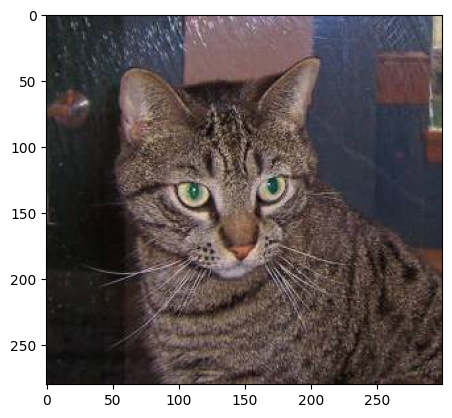

torch.Size([1, 3, 100, 100])


In [96]:
# 이미지 호출

img = cv2.imread("./dataset/dataset/training_set/cats/cat.1.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.show()

img = cv2.resize(img, (100, 100), interpolation=cv2.INTER_LINEAR)
img = ToTensor()(img).unsqueeze(0)
print(img.shape)

In [97]:
#  (0): Conv2d 특성 맵 확인

result = LayerActivations(model.features, 0)
img = img.to(device)
model(img)
activations = result.features

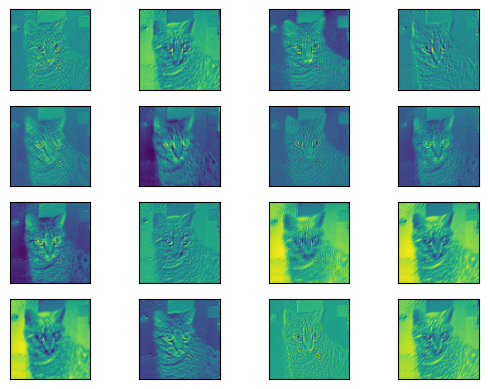

<Figure size 1200x800 with 0 Axes>

In [98]:
# 특성 맵 확인

fig, axes = plt.subplots(4, 4)
fig = plt.figure(figsize=(12,8))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)

for row in range(4):
    for column in range(4):
        axis = axes[row][column]
        axis.get_xaxis().set_ticks([])
        axis.get_yaxis().set_ticks([])
        axis.imshow(activations[0] [row*10+column])
plt.show()

In [99]:
# 40번째 계층에 대한 특성 맵

result = LayerActivations(model. features, 40) # 40번째 Conv2d 특성 맵 확인
model(img)
activations = result.features

In [100]:
# 특성 맵 확인

fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)
for row in range(4):
    for column in range(4):
        axis = axes[row][column]
        axis.get_xaxis().set_ticks([])
        axis.get_yaxis().set_ticks([])
        axis.imshow(activations[0][row*10+column])
plt.show()